In [1]:
import numpy as np

In [3]:
%load_ext autoreload
%autoreload 2

In [10]:
# training data: 
cryo_em_all_atom_path = "/home/ubuntu/MIT/Project/data/emdb_files/" # 0008.map
pdb_coordinates_path = "/home/Ubuntu/MIT/Project/data/full_pdb" 


In [47]:
from volume_utils import *
x,y,z = ft_process_volume_from_file(cryo_em_all_atom_path + "0026.map")

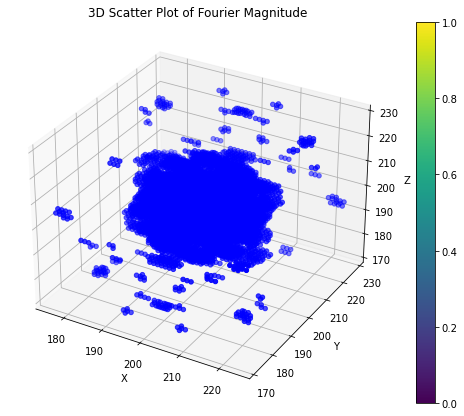

In [48]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
q =ax.scatter(y[0], y[1], y[2], c='b', marker='o')
fig.colorbar(q)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Scatter Plot of Fourier Magnitude')
plt.show()


In [40]:
y

(array([141, 143, 150, ..., 300, 307, 309]),
 array([283, 161, 150, ..., 300, 289, 167]),
 array([171, 236, 264, ..., 186, 214, 279]))

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import re
import mrcfile

class PDBVolumes(Dataset):
    def __init__(self, cryoem_vols, homolog_pdbs):
        self.cryoem_volumes = dict()
        self.process_cryoem_volumes(cryoem_vols)
        self.homolog_pdbs = dict()
        self.store_pdbs(homolog_pdbs)

    def store_cryoem_volumes(cryoem_vols):
        for file in os.listdir(cryoem_vols):
            with mrcfile.open(file, permissive=True) as mrc:
                volume = mrc.data
                # plot_slices(volume)
            

            self.cryoem_volumes[name] = vol
    
    def __init__(self, smiles_list, stoi, eos_token='.', max_seq_len=128):
        self.stoi = stoi
        self.eos_token = eos_token
        self.max_seq_len = max_seq_len
        self.smiles_list = smiles_list

    def _preprocess_smiles(self, smiles):
        tokens = preprocess_smiles(smiles)
        if len(tokens) > self.max_seq_len:
            return None  # Or handle long sequences differently
        return tokens + ['.'] * (self.max_seq_len - len(tokens))  # Pad sequences

    def __len__(self):
        return len(self.smiles_list)

    def __getitem__(self, idx):
        raw_smiles = self.smiles_list[idx]
        processed_tokens = self._preprocess_smiles(raw_smiles)
        if processed_tokens is None:
#            raise ValueError("Encountered a SMILES string longer than max_seq_len, consider filtering these out or adjusting max_seq_len.")
            return self.__getitem__(idx+1) # There's a bug in my logic somewhere, but it's ok just grab the next example ;)
        indices = [self.stoi.get(token, self.stoi[self.eos_token]) for token in processed_tokens]
        input_seq = torch.tensor(indices[:-1], dtype=torch.long)
        target_seq = torch.tensor(indices[1:], dtype=torch.long)

        return input_seq, target_seq